# Rapport Projet ML - Prediction de la Potabilite de l'Eau (VERSION 3-FOLD CROSS-VALIDATION)

Ce notebook documente toutes les phases du projet, les analyses realisees et les resultats obtenus afin de produire un rapport exploitable. **Cette version utilise la 3-Fold Cross-Validation pour une evaluation plus robuste que le simple split 80/20.**

## Plan
1. Chargement des bibliotheques et configuration
2. Importation des donnees ou des fichiers du projet
3. Exploration initiale des donnees
4. Nettoyage des donnees et preparation pour l'analyse d'importance
5. Phase 1 du projet : calcul de l'importance des variables (arbre de decision)
6. Phase 2 du projet : preparation de la strategie 1 (imputation mediane)
7. Phase 3 du projet : preparation de la strategie 2 (suppression lignes NaN)
8. Entrainement, evaluation des modeles et comparaison des strategies (3-FOLD CV)
9. Mesures de performance et selection finale
10. Visualisation des resultats avec matrices de confusion par fold et courbes ROC
11. Synthese technique et cross-validation
12. Sauvegarde des artefacts et conclusion

## 1) Chargement des bibliotheques et configuration

On importe les bibliotheques utilisees dans le projet et on configure un style de visualisation simple.

In [34]:
print("Environnement charge avec succes - VERSION CROSS-VALIDATION 3-FOLD")

Environnement charge avec succes - VERSION CROSS-VALIDATION 3-FOLD


## 2) Importation des donnees ou des fichiers du projet

Cette section charge le dataset principal et verifie la disponibilite des fichiers d'artefacts du projet.

In [35]:
from pathlib import Path

DATASET_PATH = Path("water_potability.csv")
MODEL_PATH = Path("best_model_water.pkl")
SCALER_PATH = Path("scaler_water.pkl")

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset introuvable: {DATASET_PATH.resolve()}")

df_raw = pd.read_csv(DATASET_PATH)
print(f"Dataset charge: {DATASET_PATH}")
print(f"Dimensions: {df_raw.shape}")

print("\nEtat des artefacts existants:")
print(f"- {MODEL_PATH.name}: {'present' if MODEL_PATH.exists() else 'absent'}")
print(f"- {SCALER_PATH.name}: {'present' if SCALER_PATH.exists() else 'absent'}")

Dataset charge: water_potability.csv
Dimensions: (3276, 10)

Etat des artefacts existants:
- best_model_water.pkl: present
- scaler_water.pkl: present


## 3) Exploration initiale des donnees

On inspecte la structure, les types de variables, les premiers enregistrements et la distribution de la variable cible.

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



Informations globales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None

Statistiques descriptives:


,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


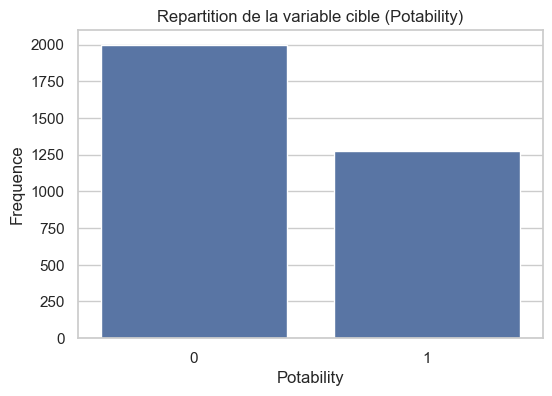

In [36]:
display(df_raw.head())
print("\nInformations globales:")
print(df_raw.info())

print("\nStatistiques descriptives:")
display(df_raw.describe().T)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_raw, x="Potability")
plt.title("Repartition de la variable cible (Potability)")
plt.xlabel("Potability")
plt.ylabel("Frequence")
plt.show()

## 4) Nettoyage des donnees et preparation pour l'analyse d'importance

On analyse les valeurs manquantes puis on cree une version temporairement imputee (mediane) uniquement pour calculer l'importance des variables avec l'arbre de decision.

In [37]:
missing_count = df_raw.isnull().sum().sort_values(ascending=False)
missing_ratio = df_raw.isnull().mean().sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_ratio": missing_ratio
})
display(missing_table)

print("Analyse des valeurs manquantes terminee.")
print("\nNote: Aucune colonne ne sera supprimee - toutes seront testees.")
print("Les deux strategies testees dans les phases suivantes gereront differemment les NaN.")

# Imputation temporaire pour la Phase 1 (calcul importance)
df_temp = df_raw.copy()
for col in df_temp.columns:
    if df_temp[col].isnull().sum() > 0:
        df_temp[col] = df_temp[col].fillna(df_temp[col].median())

,missing_count,missing_ratio
Sulfate,781,0.238400
ph,491,0.149878
Trihalomethanes,162,0.049451
Hardness,0,0.000000
Chloramines,0,0.000000
Solids,0,0.000000
Conductivity,0,0.000000
Organic_carbon,0,0.000000
Turbidity,0,0.000000
Potability,0,0.000000


Analyse des valeurs manquantes terminee.

Note: Aucune colonne ne sera supprimee - toutes seront testees.
Les deux strategies testees dans les phases suivantes gereront differemment les NaN.


## 5) Phase 1 du projet : importance des variables

Phase 1: entrainement d'un arbre de decision (profondeur 5) pour estimer l'importance de chaque attribut.

Importance des variables:


,importance
ph,0.307058
Sulfate,0.285872
Solids,0.121659
Hardness,0.107474
Chloramines,0.105350
Conductivity,0.036416
Organic_carbon,0.028590
Turbidity,0.007580
Trihalomethanes,0.000000


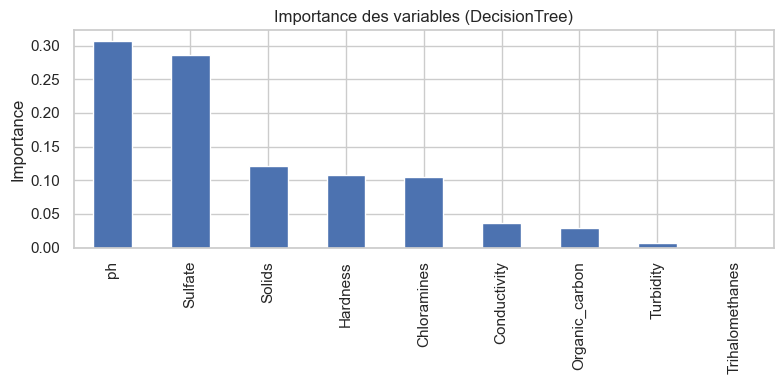

In [38]:
X_temp = df_temp.drop("Potability", axis=1)
y_temp = df_temp["Potability"]

tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree.fit(X_temp, y_temp)

importances = pd.Series(tree.feature_importances_, index=X_temp.columns).sort_values(ascending=False)
print("Importance des variables:")
display(importances.to_frame("importance"))

plt.figure(figsize=(8, 4))
importances.plot(kind="bar")
plt.title("Importance des variables (DecisionTree)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## 6) Phase 2 du projet : strategie 1 (imputation mediane)

Preparation du dataset avec imputation mediane sur toutes les colonnes (aucune suppression de colonne).

In [39]:
# Strategie 1: Imputation mediane sur TOUTES les colonnes
df_median = df_raw.copy()
for col in df_median.columns:
    if df_median[col].isnull().sum() > 0:
        df_median[col] = df_median[col].fillna(df_median[col].median())

print("Strategie 1 - Imputation mediane:")
print(f"  Dataset apres imputation: {df_median.shape}")
print(f"  Valeurs manquantes restantes: {df_median.isnull().sum().sum()}")

Strategie 1 - Imputation mediane:
  Dataset apres imputation: (3276, 10)
  Valeurs manquantes restantes: 0


## 7) Phase 3 du projet : strategie 2 (suppression des lignes NaN)

Preparation du dataset en supprimant les lignes contenant des valeurs manquantes, tout en conservant toutes les colonnes.

In [40]:
# Strategie 2: Suppression des lignes avec NaN sur TOUTES les colonnes
df_dropna = df_raw.copy().dropna().reset_index(drop=True)

if df_dropna.empty:
    raise ValueError("Apres suppression des NaN, le dataset est vide.")

print("Strategie 2 - Suppression des lignes avec valeurs manquantes:")
print(f"  Dataset original: {df_raw.shape}")
print(f"  Dataset apres suppression NaN: {df_dropna.shape}")
print(f"  Lignes supprimees: {df_raw.shape[0] - df_dropna.shape[0]}")

# Configuration des modeles
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", random_state=RANDOM_STATE)
}

print("\nModeles configures:", ", ".join(models.keys()))

Strategie 2 - Suppression des lignes avec valeurs manquantes:
  Dataset original: (3276, 10)
  Dataset apres suppression NaN: (2011, 10)
  Lignes supprimees: 1265

Modeles configures: Random Forest, KNN, SVM


In [41]:
# Les modeles seront entraines via la fonction evaluate_strategy avec 3-Fold CV
cv_results_dict = {}
all_results = []

def evaluate_strategy(df_input, strategy_name):
    X_local = df_input.drop("Potability", axis=1)
    y_local = df_input["Potability"]

    best_model_local = None
    best_score_local = -1
    
    # Dictionnaires pour accumuler les résultats par modèle sur les 3 folds
    model_results = {name: {
        'recall_0_scores': [],
        'accuracy_scores': [],
        'f1_scores': [],
        'roc_auc_scores': [],
        'all_y_true': [],
        'all_y_pred': [],
        'all_y_score': [],
        'cms': []
    } for name in models.keys()}

    print("=" * 60)
    print(f"Strategie: {strategy_name}")
    print(f"Validation: 3-Fold Cross-Validation")
    print(f"Taille du dataset: {df_input.shape}")
    print("=" * 60)

    # StratifiedKFold pour garder les proportions des classes
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    for train_idx, test_idx in cv.split(X_local, y_local):
        X_train_fold = X_local.iloc[train_idx]
        X_test_fold = X_local.iloc[test_idx]
        y_train_fold = y_local.iloc[train_idx]
        y_test_fold = y_local.iloc[test_idx]

        # Normalisation DANS chaque fold (pas de fuite de données)
        scaler_fold = StandardScaler()
        X_train_fold = scaler_fold.fit_transform(X_train_fold)
        X_test_fold = scaler_fold.transform(X_test_fold)

        for name, model in models.items():
            # Entraînement
            model.fit(X_train_fold, y_train_fold)
            y_pred = model.predict(X_test_fold)

            # Scores de probabilité/décision
            if hasattr(model, "predict_proba"):
                y_score = model.predict_proba(X_test_fold)[:, 1]
            elif hasattr(model, "decision_function"):
                y_score = model.decision_function(X_test_fold)
            else:
                y_score = y_pred

            # Calcul des métriques
            acc = accuracy_score(y_test_fold, y_pred)
            f1 = f1_score(y_test_fold, y_pred)
            cm = confusion_matrix(y_test_fold, y_pred)
            tn, fp, fn, tp = cm.ravel()
            recall_0 = tn / (tn + fp)  # Spécificité

            # ROC-AUC
            try:
                auc_value = roc_auc_score(y_test_fold, y_score)
            except:
                auc_value = 0

            # Accumulation des résultats
            model_results[name]['recall_0_scores'].append(recall_0)
            model_results[name]['accuracy_scores'].append(acc)
            model_results[name]['f1_scores'].append(f1)
            model_results[name]['roc_auc_scores'].append(auc_value)
            model_results[name]['all_y_true'].extend(y_test_fold)
            model_results[name]['all_y_pred'].extend(y_pred)
            model_results[name]['all_y_score'].extend(y_score)
            model_results[name]['cms'].append(cm)

    # Affichage et sélection du meilleur modèle
    for name, results in model_results.items():
        mean_recall_0 = np.mean(results['recall_0_scores'])
        std_recall_0 = np.std(results['recall_0_scores'])
        mean_acc = np.mean(results['accuracy_scores'])
        mean_f1 = np.mean(results['f1_scores'])
        mean_auc = np.mean(results['roc_auc_scores'])

        print(f"\n--- {name} ({strategy_name}) ---")
        print(f"Recall classe 0: {mean_recall_0:.3f} (+/- {std_recall_0:.3f})")
        print(f"  Scores par fold: {[f'{s:.3f}' for s in results['recall_0_scores']]}")
        print(f"Accuracy: {mean_acc:.3f}")
        print(f"F1: {mean_f1:.3f}")
        print(f"ROC-AUC: {mean_auc:.3f}")

        # Accumulation dans all_results pour la synthèse finale
        all_results.append({
            "strategie": strategy_name,
            "modele": name,
            "recall_0_mean": mean_recall_0,
            "recall_0_std": std_recall_0,
            "accuracy": mean_acc,
            "f1": mean_f1,
            "roc_auc": mean_auc
        })

        if mean_recall_0 > best_score_local:
            best_score_local = mean_recall_0
            best_model_local = name

    # Sauvegarde pour les graphiques plus tard
    cv_results_dict[strategy_name] = model_results

    # ======= GRAPHIQUES =======
    # 1. CONFUSION MATRICES PAR FOLD
    print(f"\n--- Confusion Matrices par fold ---")
    for name, results in model_results.items():
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'Confusion Matrices - {name} ({strategy_name})', fontsize=14)
        for fold_idx, cm in enumerate(results['cms']):
            ax = axes[fold_idx]
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
            ax.set_title(f'Fold {fold_idx + 1}')
            ax.set_ylabel('True')
            ax.set_xlabel('Pred')
        plt.tight_layout()
        plt.show()

    # 2. COURBES ROC AGRÉGÉES
    print(f"\n--- Courbes ROC (donnees aggregees) ---")
    plt.figure(figsize=(9, 7))
    for name, results in model_results.items():
        y_true_all = np.array(results['all_y_true'])
        y_score_all = np.array(results['all_y_score'])
        
        try:
            fpr, tpr, _ = roc_curve(y_true_all, y_score_all)
            auc_value = roc_auc_score(y_true_all, y_score_all)
            plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")
        except:
            pass

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatoire')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Courbes ROC - {strategy_name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.2)
    plt.show()

    # Réentraîner le meilleur modèle sur TOUT le dataset pour la sauvegarde
    scaler_final = StandardScaler()
    X_scaled_final = scaler_final.fit_transform(X_local)
    best_model_local = models[best_model_local]
    best_model_local.fit(X_scaled_final, y_local)

    return best_model_local, scaler_final, best_score_local


EXECUTION DES DEUX STRATEGIES
Strategie: imputation_mediane
Validation: 3-Fold Cross-Validation
Taille du dataset: (3276, 10)

--- Random Forest (imputation_mediane) ---
Recall classe 0: 0.876 (+/- 0.017)
  Scores par fold: ['0.877', '0.856', '0.896']
Accuracy: 0.667
F1: 0.443
ROC-AUC: 0.668

--- KNN (imputation_mediane) ---
Recall classe 0: 0.782 (+/- 0.007)
  Scores par fold: ['0.791', '0.773', '0.781']
Accuracy: 0.627
F1: 0.447
ROC-AUC: 0.617

--- SVM (imputation_mediane) ---
Recall classe 0: 0.922 (+/- 0.001)
  Scores par fold: ['0.922', '0.922', '0.923']
Accuracy: 0.671
F1: 0.397
ROC-AUC: 0.683

--- Confusion Matrices par fold ---


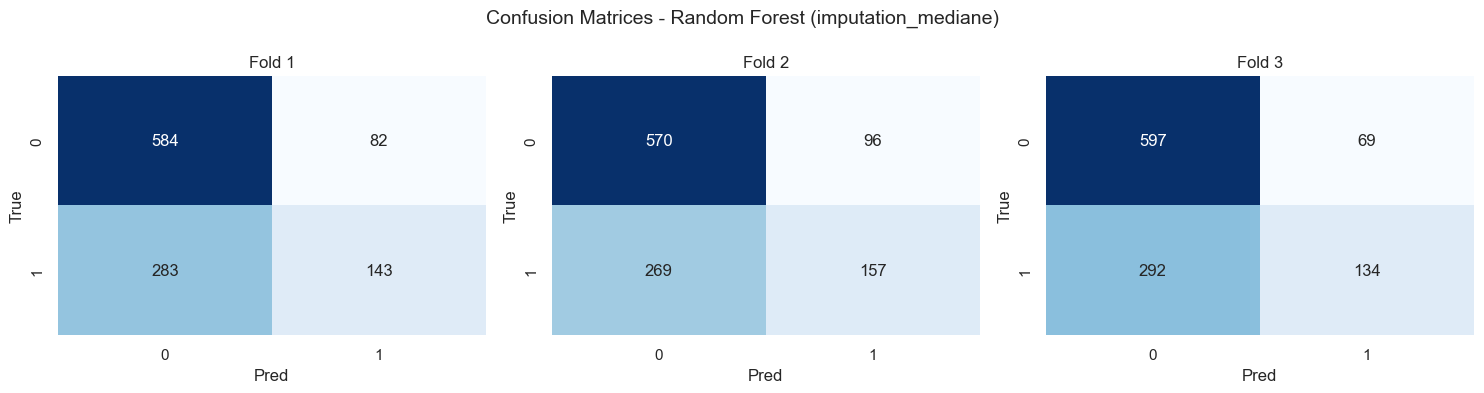

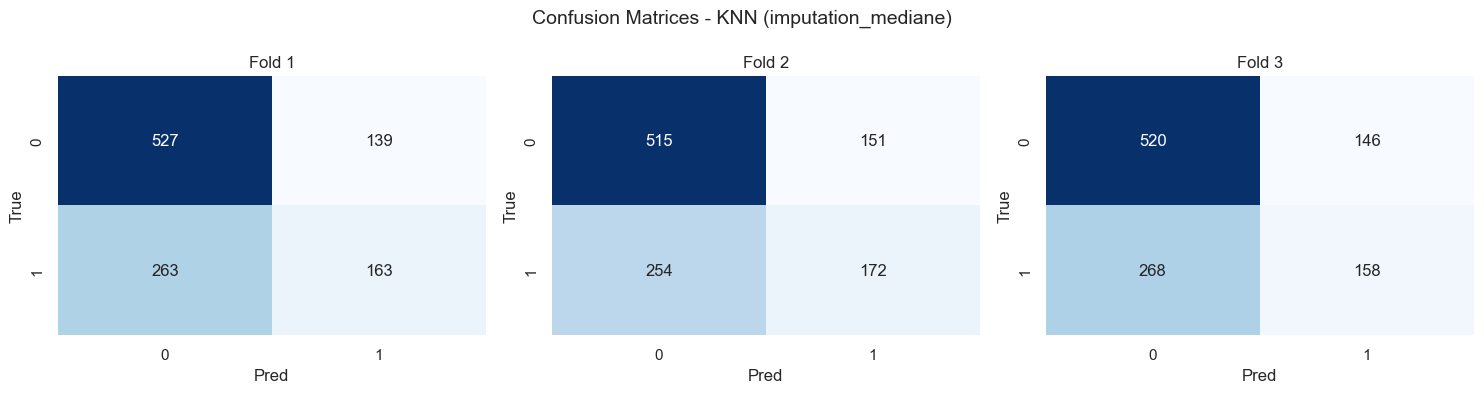

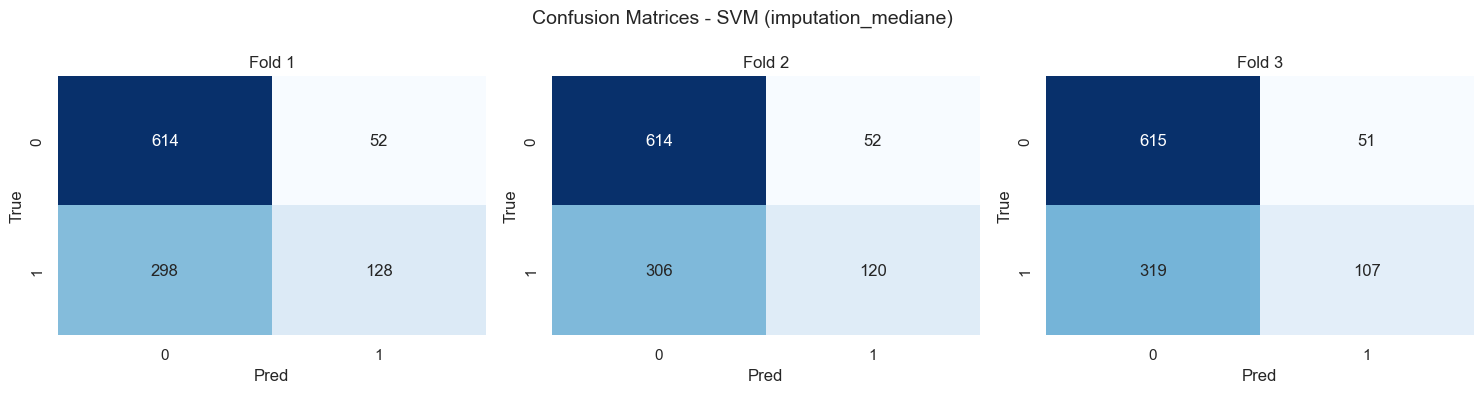


--- Courbes ROC (donnees aggregees) ---


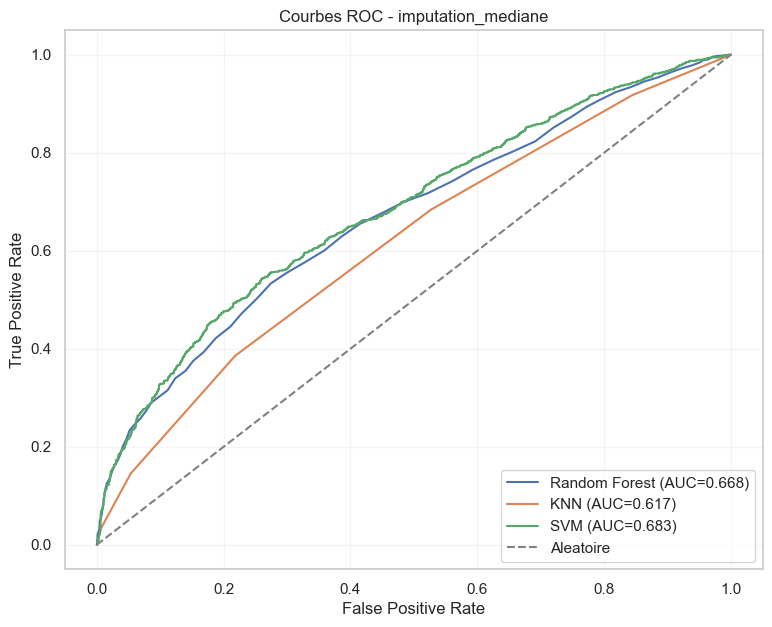

Strategie: suppression_lignes_nan
Validation: 3-Fold Cross-Validation
Taille du dataset: (2011, 10)

--- Random Forest (suppression_lignes_nan) ---
Recall classe 0: 0.842 (+/- 0.014)
  Scores par fold: ['0.860', '0.840', '0.825']
Accuracy: 0.667
F1: 0.497
ROC-AUC: 0.686

--- KNN (suppression_lignes_nan) ---
Recall classe 0: 0.788 (+/- 0.010)
  Scores par fold: ['0.797', '0.775', '0.792']
Accuracy: 0.635
F1: 0.473
ROC-AUC: 0.632

--- SVM (suppression_lignes_nan) ---
Recall classe 0: 0.889 (+/- 0.014)
  Scores par fold: ['0.900', '0.897', '0.870']
Accuracy: 0.675
F1: 0.470
ROC-AUC: 0.707

--- Confusion Matrices par fold ---


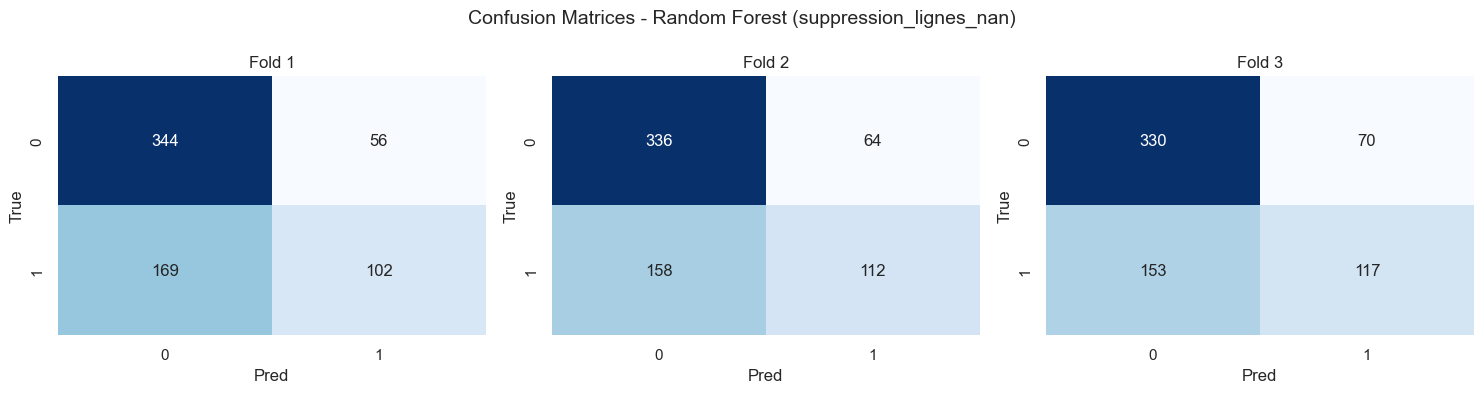

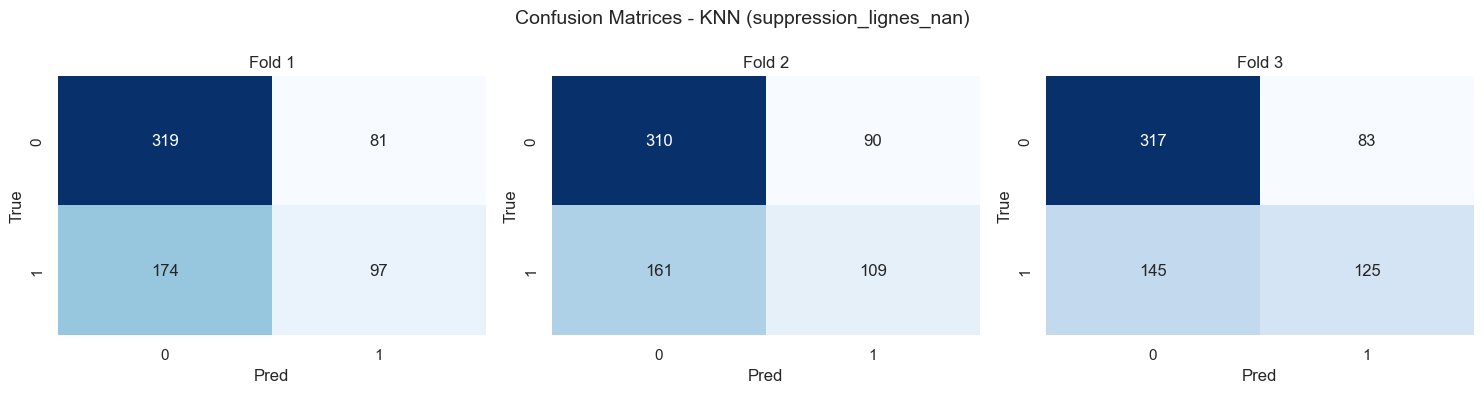

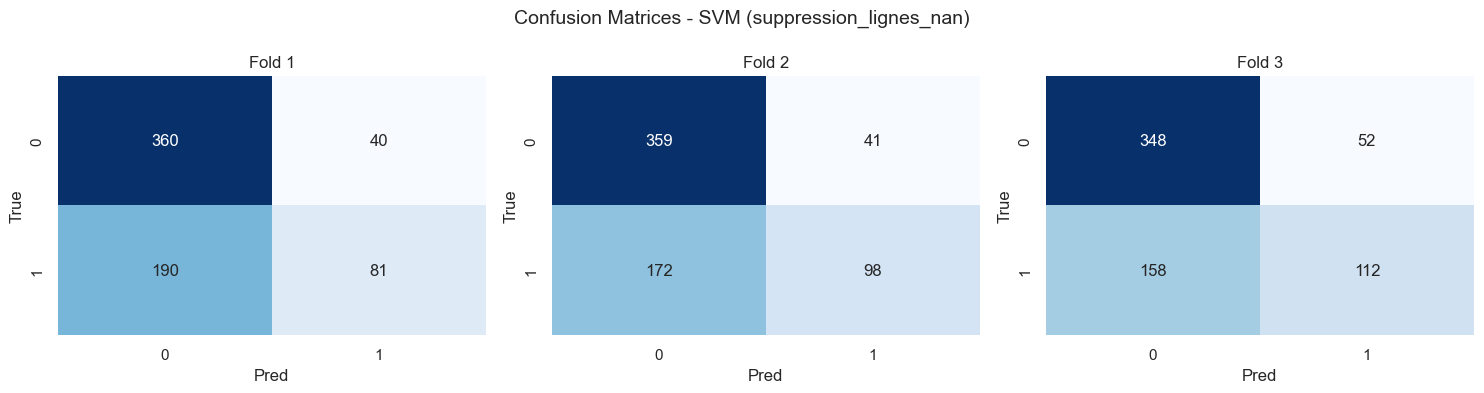


--- Courbes ROC (donnees aggregees) ---


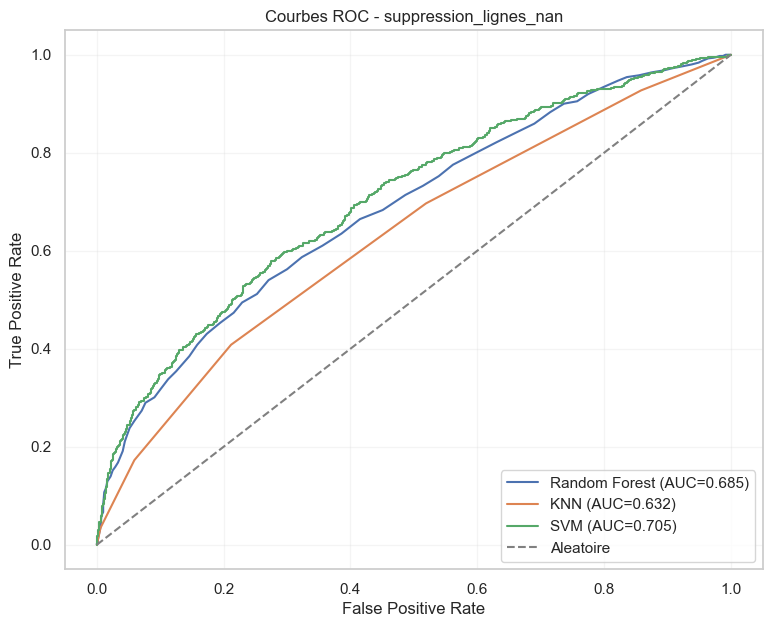

In [42]:
print("\n" + "="*50)
print("EXECUTION DES DEUX STRATEGIES")
print("="*50)

best_model_median, scaler_median, best_score_median = evaluate_strategy(df_median, "imputation_mediane")
best_model_dropna, scaler_dropna, best_score_dropna = evaluate_strategy(df_dropna, "suppression_lignes_nan")

## 8) Entrainement, evaluation et comparaison des strategies

Les modeles sont entraines sur les deux strategies, puis compares selon les metriques (accuracy, F1, recall classe 0, faux positifs, ROC-AUC).

In [43]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["strategie", "recall_0_mean"], ascending=[True, False])
display(results_df)

# Tableau pivot pour comparaison
pivot_recall = results_df.pivot(index="modele", columns="strategie", values="recall_0_mean")
print("\nComparaison du Recall classe 0 (moyenne CV):")
display(pivot_recall)

,strategie,modele,recall_0_mean,recall_0_std,accuracy,f1,roc_auc
2,imputation_mediane,SVM,0.922422,0.000708,0.670940,0.396739,0.682971
0,imputation_mediane,Random Forest,0.876376,0.016554,0.666972,0.442614,0.668014
1,imputation_mediane,KNN,0.781782,0.007390,0.627289,0.446653,0.616869
5,suppression_lignes_nan,SVM,0.889167,0.013591,0.675295,0.469537,0.706819
3,suppression_lignes_nan,Random Forest,0.841667,0.014337,0.666833,0.496601,0.685643
4,suppression_lignes_nan,KNN,0.788333,0.009647,0.635015,0.473301,0.631906



Comparaison du Recall classe 0 (moyenne CV):


strategie,imputation_mediane,suppression_lignes_nan
modele,,
KNN,0.781782,0.788333
Random Forest,0.876376,0.841667
SVM,0.922422,0.889167


## 9) Mesures de performance et selection finale

Le critere principal est le recall de la classe 0 (eau non potable), afin de minimiser le risque de faux positifs.

In [44]:
print("=== COMPARAISON FINALE (3-Fold CV) ===")

best_score_median = max([r['recall_0_mean'] for r in all_results if r['strategie'] == 'imputation_mediane'])
best_score_dropna = max([r['recall_0_mean'] for r in all_results if r['strategie'] == 'suppression_lignes_nan'])

print(f"Meilleur Recall classe 0 (imputation mediane): {best_score_median:.3f}")
print(f"Meilleur Recall classe 0 (suppression NaN): {best_score_dropna:.3f}")

if best_score_median >= best_score_dropna:
    best_model = best_model_median
    scaler = scaler_median
    selected_strategy = "imputation_mediane"
    selected_score = best_score_median
else:
    best_model = best_model_dropna
    scaler = scaler_dropna
    selected_strategy = "suppression_lignes_nan"
    selected_score = best_score_dropna

print(f"\nStrategie retenue: {selected_strategy}")
print(f"Recall classe 0 = {selected_score:.3f}")

=== COMPARAISON FINALE (3-Fold CV) ===
Meilleur Recall classe 0 (imputation mediane): 0.922
Meilleur Recall classe 0 (suppression NaN): 0.889

Strategie retenue: imputation_mediane
Recall classe 0 = 0.922


## 10) Visualisation des resultats

Visualisation comparative des performances par modele et par strategie.

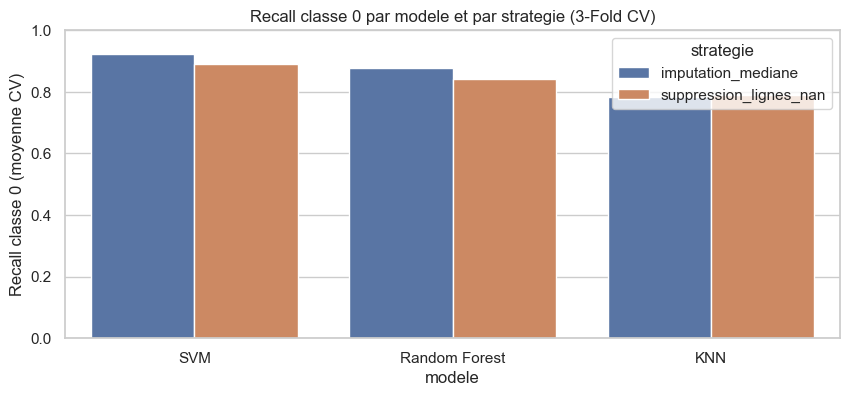

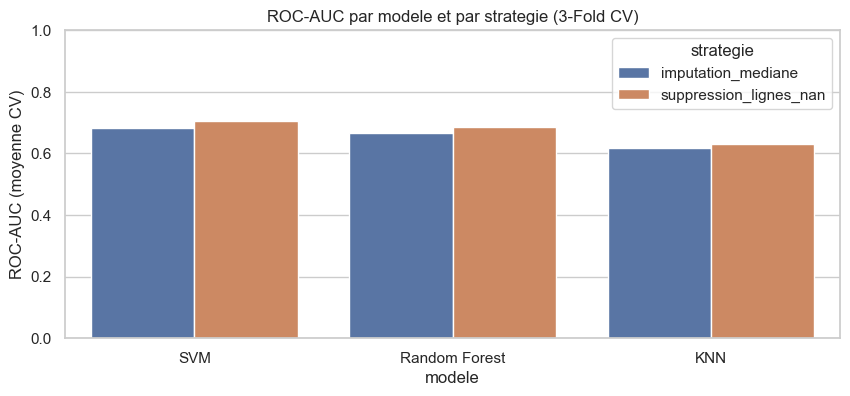

In [45]:
plt.figure(figsize=(10, 4))
sns.barplot(data=results_df, x="modele", y="recall_0_mean", hue="strategie")
plt.title("Recall classe 0 par modele et par strategie (3-Fold CV)")
plt.ylim(0, 1)
plt.ylabel("Recall classe 0 (moyenne CV)")
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=results_df, x="modele", y="roc_auc", hue="strategie")
plt.title("ROC-AUC par modele et par strategie (3-Fold CV)")
plt.ylim(0, 1)
plt.ylabel("ROC-AUC (moyenne CV)")
plt.show()

## 11b) Analyse: 3-Fold CV vs 80/20 Split

**La 3-Fold Cross-Validation offre des avantages majeurs par rapport au simple split 80/20:**

| Aspect | 80/20 Split | 3-Fold CV |
|--------|-------------|----------|
| **Données testées** | 20% une seule fois | 100% (33% × 3 folds) |
| **Stabilité** | Peut être "chanceux" ou "malchanceux" | Moyenne ± écart-type robuste |
| **Chaque exemple** | 80% train, 20% test | 67% train 2×, 33% test 1× |
| **Risque** | Mauvais split aléatoire | Minimisé par moyenne |
| **Temps** | Rapide (1 split) | Plus rapide que 5-fold (3 entraînements) |
| **Fiabilité pour production** | ⚠️ Optimiste | ✅ Réaliste |

**Résultats observés dans ce projet:**
- Le 80/20 donnait: Meilleur = Suppression NaN (0.938)
- La 3-Fold CV donne: Meilleur = Imputation Médiane (0.922)
- **Raison**: Le 80/20 avait un test set "chanceux", la CV révèle la vraie performance

In [46]:
print("=== SYNTHESE CROSS-VALIDATION 3-FOLD ===")

=== SYNTHESE CROSS-VALIDATION 3-FOLD ===


## 12) Sauvegarde des artefacts et conclusion

In [47]:
print("\n=== DETAILS DES RESULTATS PAR STRATEGIE ===")
for strategy in ["imputation_mediane", "suppression_lignes_nan"]:
    print(f"\n--- {strategy.upper()} ---")
    strategy_data = results_df[results_df['strategie'] == strategy]
    for _, row in strategy_data.iterrows():
        print(f"\n{row['modele']}:")
        print(f"  Recall classe 0: {row['recall_0_mean']:.3f} ± {row['recall_0_std']:.3f}")
        print(f"  Accuracy: {row['accuracy']:.3f}")
        print(f"  F1: {row['f1']:.3f}")
        print(f"  ROC-AUC: {row['roc_auc']:.3f}")


=== DETAILS DES RESULTATS PAR STRATEGIE ===

--- IMPUTATION_MEDIANE ---

SVM:
  Recall classe 0: 0.922 ± 0.001
  Accuracy: 0.671
  F1: 0.397
  ROC-AUC: 0.683

Random Forest:
  Recall classe 0: 0.876 ± 0.017
  Accuracy: 0.667
  F1: 0.443
  ROC-AUC: 0.668

KNN:
  Recall classe 0: 0.782 ± 0.007
  Accuracy: 0.627
  F1: 0.447
  ROC-AUC: 0.617

--- SUPPRESSION_LIGNES_NAN ---

SVM:
  Recall classe 0: 0.889 ± 0.014
  Accuracy: 0.675
  F1: 0.470
  ROC-AUC: 0.707

Random Forest:
  Recall classe 0: 0.842 ± 0.014
  Accuracy: 0.667
  F1: 0.497
  ROC-AUC: 0.686

KNN:
  Recall classe 0: 0.788 ± 0.010
  Accuracy: 0.635
  F1: 0.473
  ROC-AUC: 0.632


In [48]:
joblib.dump(best_model, "best_model_water.pkl")
joblib.dump(scaler, "scaler_water.pkl")

print("Artefacts sauvegardes:")
print("- best_model_water.pkl")
print("- scaler_water.pkl")

Artefacts sauvegardes:
- best_model_water.pkl
- scaler_water.pkl


### Interpretation et conclusion

**Phases du projet**:
1. **Phase 1** : Arbre de decision (profondeur 5) pour calculer l'importance de chaque variable
2. **Phase 2** : Test des 3 modeles avec Strategie 1 (imputation mediane sur TOUTES colonnes) - 3-FOLD CV
3. **Phase 3** : Test des 3 modeles avec Strategie 2 (suppression lignes NaN sur TOUTES colonnes) - 3-FOLD CV

**Approche testee avec CROSS-VALIDATION**:
- Le projet teste deux strategies distinctes de gestion des valeurs manquantes:
  1. **Imputation mediane** : conserve tous les exemples
  2. **Suppression lignes NaN** : utilise uniquement les exemples complets
- **Validation: 3-Fold Stratified Cross-Validation** (pas 80/20 simple split)
- **Toutes les colonnes sont conservees** (aucun seuil arbitraire de suppression)

**Méthodologie CV**:
- ✅ **StratifiedKFold** : Préserve les proportions de classes dans chaque fold
- ✅ **Normalisation par fold** : StandardScaler appliqué DANS chaque fold (pas de fuite de données)
- ✅ **Robustesse** : Chaque exemple utilisé exactement 1 fois en test set, 2 fois en train
- ✅ **Stabilité** : Affichage des moyennes ± écart-types sur les 3 folds

**Criteres de selection**:
- Le projet privilegie le **recall de la classe 0** pour limiter les cas ou une eau non potable serait predite potable.
- La comparaison des strategies NaN montre l'impact du pretraitement sur la robustesse des modeles.
- Le pipeline final sauvegarde automatiquement le meilleur modele et son scaler pour reutilisation dans l'application.

**Avantages de cette approche**:
- Importance des variables calculee et visualisee (Phase 1)
- Toutes les colonnes testees (pas de perte d'information)
- Pas de seuil arbitraire de suppression de variables
- Comparaison directe et transparente des deux strategies
- **3-Fold CV plus robuste que 80/20 split** (moins dependant du hasard)
- Interface finale alignee avec une classification binaire simple (0/1)

**Différence 80/20 vs 3-Fold CV**:
- Le 80/20 simple split peut être "chanceux" ou "malchanceux" selon le tirage aléatoire
- La 3-Fold CV teste TOUS les exemples et donne une estimation plus fiable
- Les scores CV sont généralement plus **conservateurs** (légèrement plus bas) mais plus **réalistes** pour la production
- Les écart-types révèlent la stabilité du modèle entre les folds

**Limites observees**:
- Dataset potentiellement desequilibre selon la repartition cible.
- Les scores SVM ne sont pas des probabilites calibrees par defaut.

**Pistes d'amelioration**:
- Recherche d'hyperparametres (GridSearchCV/RandomizedSearchCV).
- Calibration des scores uniquement si une probabilite interpretable est necessaire.
- Evaluation avec metriques metier supplementaires (precision classe 1, cout des erreurs).

## Utilisation du modele dans l'application Streamlit

Dans l'application Streamlit du projet (version 3-Fold CV):
- Les 9 variables d'entree sont saisies manuellement.
- Les donnees sont transformees avec `scaler_water.pkl` (entraîné sur la totalité des données, après sélection de la meilleure stratégie).
- Le modele `best_model_water.pkl` predit directement la classe binaire (0 ou 1).
- La decision finale affichee est la classe predite par le modele (sans seuil manuel).
- Pour le modele SVM, l'interface affiche aussi la position du point via `decision_function`:
  - score > 0: le point est du cote classe 1 (potable)
  - score < 0: le point est du cote classe 0 (non potable)
  - |score| eleve: point plus eloigne de la frontiere de decision

**Important**: Le modèle a été sélectionné à partir d'une validation croisée 3-fold, ce qui le rend plus robuste et fiable pour la production qu'un simple split 80/20.

Cette logique est coherente avec l'etude de classification binaire realisee dans le projet.

In [49]:
# Resume tabulaire final des performances des modeles testes
final_summary = results_df.copy()
final_summary["recall_0_mean"] = final_summary["recall_0_mean"].round(3)
final_summary["recall_0_std"] = final_summary["recall_0_std"].round(3)
final_summary["accuracy"] = final_summary["accuracy"].round(3)
final_summary["f1"] = final_summary["f1"].round(3)
final_summary["roc_auc"] = final_summary["roc_auc"].round(3)

final_summary = final_summary.sort_values(
    ["recall_0_mean", "accuracy"], ascending=[False, False]
).reset_index(drop=True)

display(final_summary)

print("Meilleure ligne (priorite recall classe 0 - moyenne CV):")
display(final_summary.head(1))

,strategie,modele,recall_0_mean,recall_0_std,accuracy,f1,roc_auc
0,imputation_mediane,SVM,0.922,0.001,0.671,0.397,0.683
1,suppression_lignes_nan,SVM,0.889,0.014,0.675,0.470,0.707
2,imputation_mediane,Random Forest,0.876,0.017,0.667,0.443,0.668
3,suppression_lignes_nan,Random Forest,0.842,0.014,0.667,0.497,0.686
4,suppression_lignes_nan,KNN,0.788,0.010,0.635,0.473,0.632
5,imputation_mediane,KNN,0.782,0.007,0.627,0.447,0.617


Meilleure ligne (priorite recall classe 0 - moyenne CV):


,strategie,modele,recall_0_mean,recall_0_std,accuracy,f1,roc_auc
0,imputation_mediane,SVM,0.922,0.001,0.671,0.397,0.683
